In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.info()

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount  

In [4]:
# Descriptive Statistics

print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode().iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID               1
Date                2023-05-16
Customer ID            CUST001
Gender                  Female
Age                       43.0
Product Category      Clothing
Quantity                   4.0
Price per Unit            50.0
Total Amount              50.0
Name: 0, dtype: object

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


## Observation

The dataset contains customer age, quantity purchased, price per unit, and total transaction amount.

The average customer age and spending patterns provide a general understanding of customer behavior. Standard deviation values indicate the variability in purchase quantities and transaction values.

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

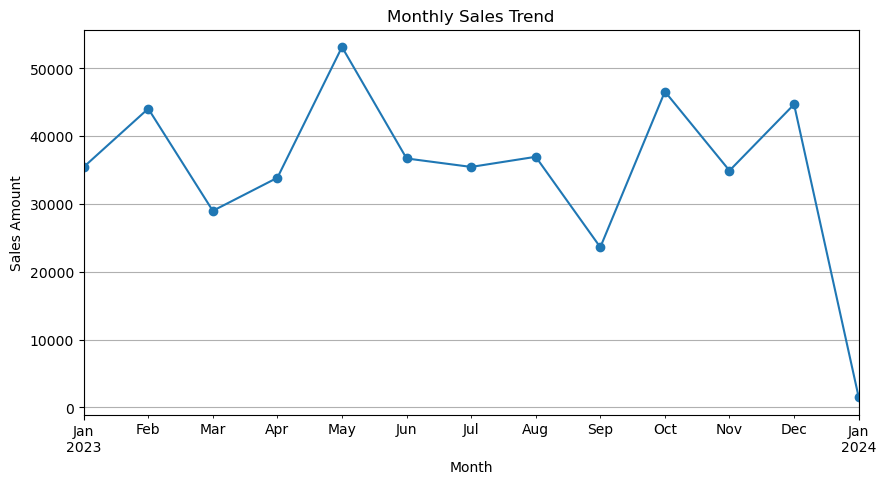

In [6]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales.plot(
    kind='line',
    figsize=(10,5),
    marker='o',
    title='Monthly Sales Trend'
)

plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

## Observation

The monthly sales trend shows fluctuations in customer purchasing behavior throughout the year.

Months with higher sales indicate periods of stronger demand and may represent seasonal purchasing trends.

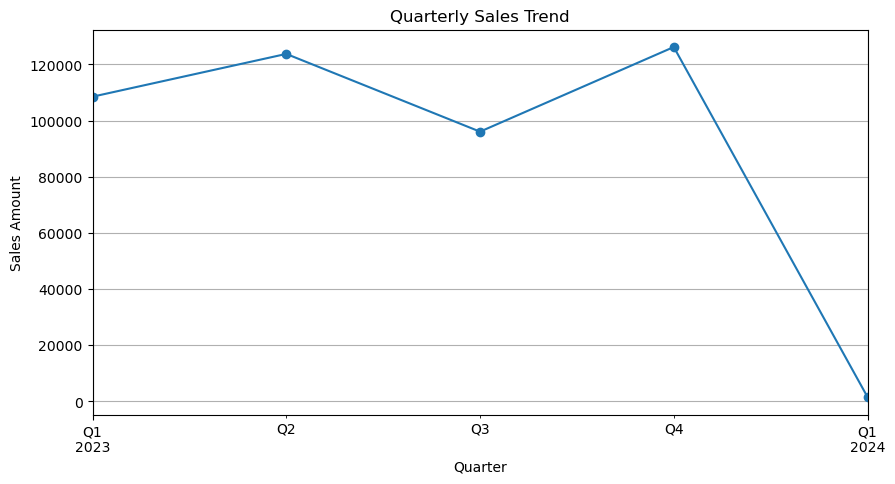

In [7]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales.plot(
    kind='line',
    figsize=(10,5),
    marker='o',
    title='Quarterly Sales Trend'
)

plt.xlabel("Quarter")
plt.ylabel("Sales Amount")
plt.grid(True)
plt.show()

## Observation

Quarterly analysis helps identify long-term business trends and seasonal performance differences across the year.

## Observation

The decline in Q1 2024 sales is due to incomplete quarter data,
as only January 2024 records are available in the dataset.
Therefore, Q1 2024 should not be directly compared with
previous complete quarters.

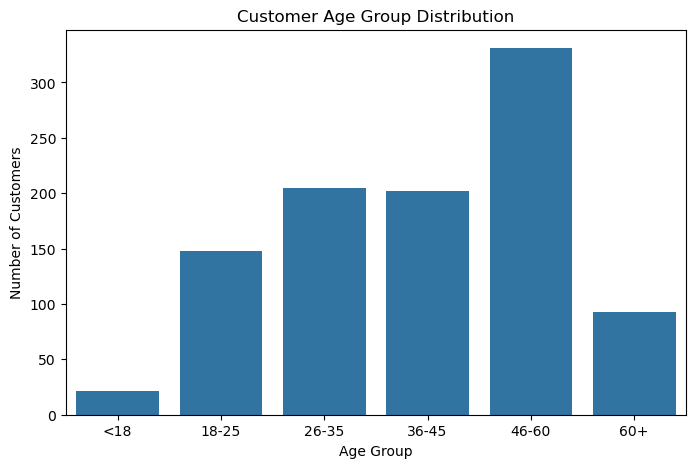

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']

df['Age Group'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(x='Age Group', data=df)

plt.title('Customer Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.show()

## Observation

This chart shows which age groups contribute the most customers.
The business can target marketing campaigns towards the dominant
age segments.

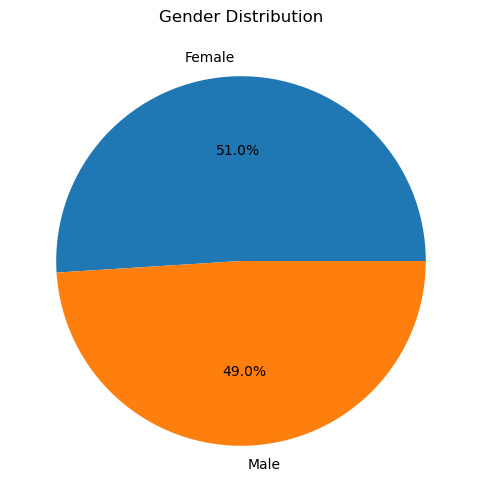

In [9]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

## Observation

The gender distribution indicates the proportion of male and female customers.
This helps understand customer demographics and marketing opportunities.

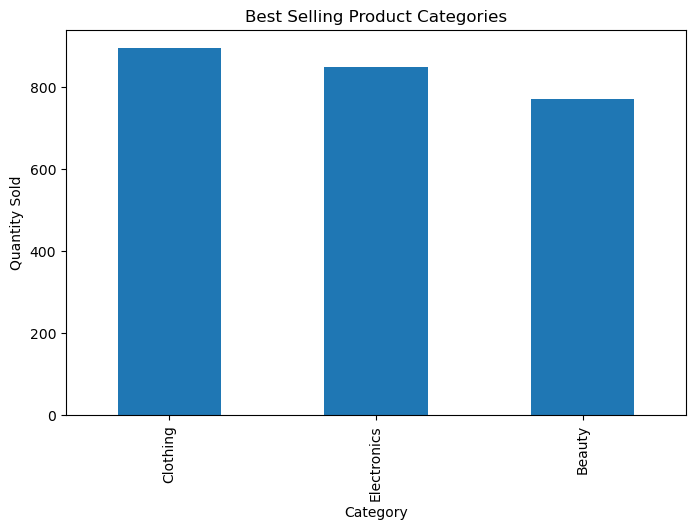

In [10]:
top_products = df.groupby(
    'Product Category'
)['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')

plt.title('Best Selling Product Categories')
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
plt.show()

## Observation

The best-selling product categories represent the products most frequently purchased by customers.

These categories demonstrate strong customer demand and should be maintained with adequate stock levels. Understanding customer preferences can help businesses optimize product offerings and improve overall sales performance.

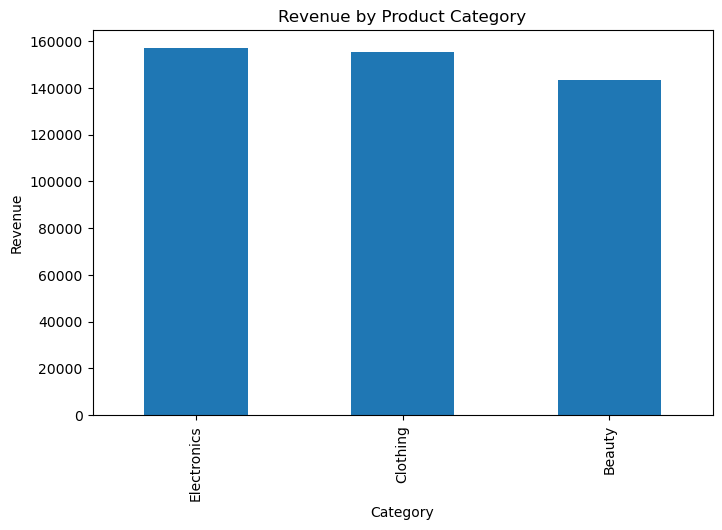

In [11]:
revenue = df.groupby(
    'Product Category'
)['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

## Observation

The revenue analysis reveals that certain product categories contribute significantly more revenue than others.

Higher-revenue categories should be prioritized for inventory planning, marketing campaigns, and customer engagement strategies. Lower-performing categories may require promotional offers or product diversification to improve sales performance.

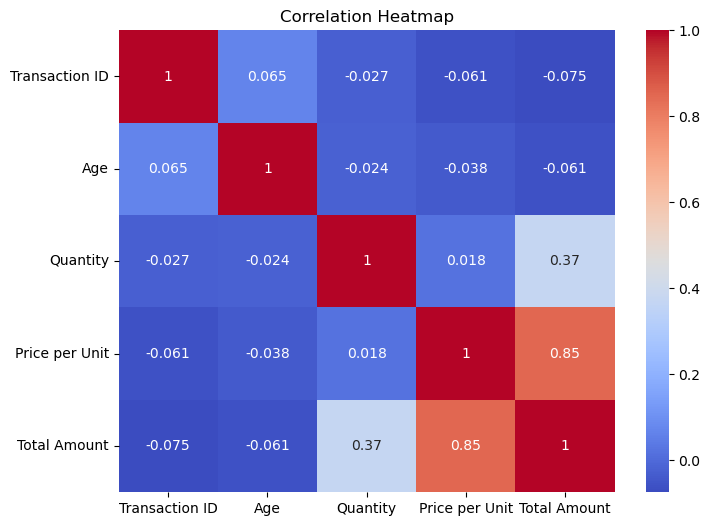

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

## Observation

The correlation heatmap highlights the relationships between numerical variables in the dataset.

A strong positive correlation between Quantity and Total Amount suggests that larger purchases generate higher revenue. Variables with weak correlations indicate limited influence on each other. These insights help identify the key drivers of sales performance.

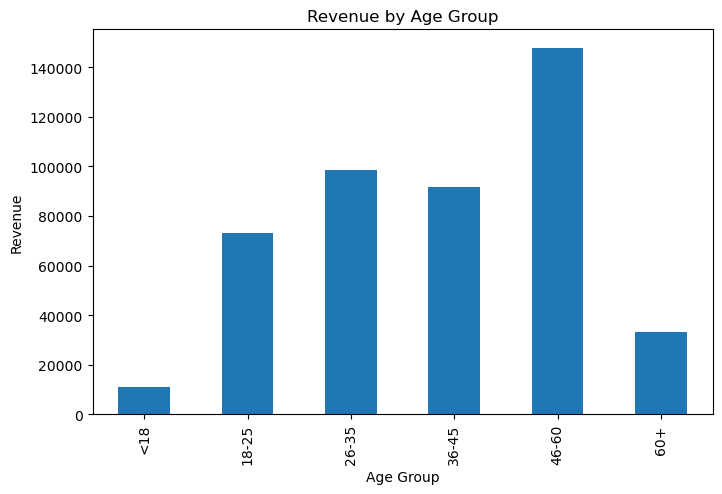

In [14]:
age_revenue = df.groupby(
    'Age Group',
    observed=False
)['Total Amount'].sum()

plt.figure(figsize=(8,5))
age_revenue.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue')
plt.show()

## Observation

Although some age groups have fewer customers,
they may contribute disproportionately higher revenue.
This insight can help target high-value customer segments.


# Conclusion

1. The Clothing category generated the highest sales and revenue,
   making it a key focus area for inventory management.

2. Customers aged 26–45 contributed a significant portion of sales,
   suggesting targeted promotions for this segment.

3. Sales peaked during specific months and quarters,
   indicating seasonal buying behaviour that can be leveraged
   through strategic marketing campaigns.

4. Product categories with lower sales may benefit from
   promotional offers or bundle strategies.

5. Gender-based purchasing trends can be used to design
   more personalized marketing campaigns.

# Conclusion and Recommendations

## Key Findings

1. Sales fluctuate across months, indicating seasonal purchasing patterns.

2. Certain product categories contribute significantly more revenue than others.

3. Customer demographics show that specific age groups generate higher sales.

4. Strong correlations exist between quantity sold and total revenue.

## Business Recommendations

1. Increase inventory and promotional efforts for top-performing product categories.

2. Focus marketing campaigns on the highest revenue-generating age groups.

3. Launch seasonal offers during peak sales periods to maximize revenue.

4. Develop targeted customer engagement strategies based on demographic insights.

5. Monitor low-performing categories and consider promotional discounts to improve sales.